In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-05-17 20:06:14.133421: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-17 20:06:14.173610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/yash/.local/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/yash/.local/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime versio

In [2]:
# =========================
# 2. LOAD DATASET (SAFE)
# =========================
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

print("Dataset Loaded ✅")
print(df.head())
print(df.columns)

Dataset Loaded ✅
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')


In [3]:
df = df.dropna()
print(df['sentiment'].unique())
print(df['sentiment'].isnull().sum())
df = df.dropna()


['positive' 'negative']
0


In [4]:
print(df['sentiment'].unique())   # should be [0,1]
print(df.isnull().sum())          # should be 0

['positive' 'negative']
review       0
sentiment    0
dtype: int64


In [5]:
# =========================
# 3. FIX COLUMN NAMES
# =========================
df.columns = ['review', 'sentiment']

In [6]:
# =========================
# 4. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove symbols
    return text

df['review'] = df['review'].apply(clean_text)

In [7]:
# =========================
# 5. CONVERT LABELS
# =========================
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())


Sentiment Count:
sentiment
0    24813
1    24799
Name: count, dtype: int64


In [8]:
# =========================
# 6. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

In [9]:

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# =========================
# 8. BUILD MODEL
# =========================
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/yash/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-17 20:06:22.557976: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:


# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10


2026-05-17 20:06:23.328260: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 793780000 exceeds 10% of free system memory.


1222/1241 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8382 - loss: 0.3747

2026-05-17 20:06:27.820149: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 198460000 exceeds 10% of free system memory.


1241/1241 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8675 - loss: 0.3116 - val_accuracy: 0.8890 - val_loss: 0.2677
Epoch 2/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9044 - loss: 0.2321 - val_accuracy: 0.8861 - val_loss: 0.2776
Epoch 3/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9285 - loss: 0.1793 - val_accuracy: 0.8856 - val_loss: 0.2950
Epoch 4/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9746 - loss: 0.0788 - val_accuracy: 0.8815 - val_loss: 0.3849
Epoch 5/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9949 - loss: 0.0184 - val_accuracy: 0.8829 - val_loss: 0.5066
Epoch 6/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9996 - loss: 0.0029 - val_accuracy: 0.8780 - val_loss: 0.7139
Epoch 7/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 4.8351e-04 - val_accuracy: 0.8799 - val_loss: 0.8078
Epoch 8/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.0755e-04 - val

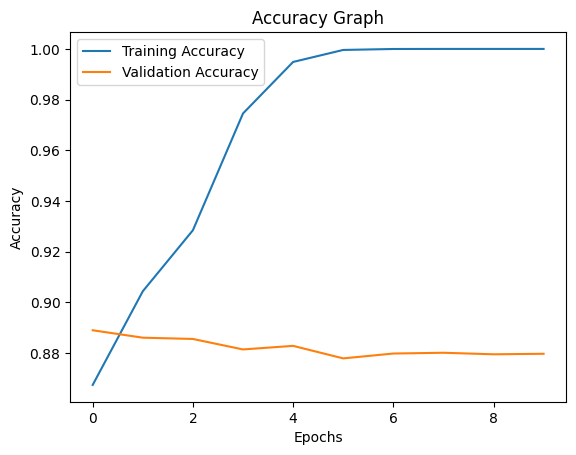

In [12]:
# =========================
# 10. PLOT GRAPH
# =========================
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
# =========================
# 11. FINAL ACCURACY
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Accuracy:", accuracy)

215/311 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - accuracy: 0.8794 - loss: 1.0403

2026-05-17 20:06:59.585400: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 198460000 exceeds 10% of free system memory.


311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.8798 - loss: 1.0318

Final Accuracy: 0.879774272441864


In [14]:
# =========================
# 12. SENTIMENT PREDICTION FUNCTION
# =========================
def predict_sentiment(sentence):
    """
    Predict sentiment of a given sentence
    
    Parameters:
    -----------
    sentence : str
        The text to classify
    
    Returns:
    --------
    dict : Contains sentiment label and confidence score
    """
    # Clean the text
    cleaned = clean_text(sentence)
    
    # Vectorize the text
    vectorized = vectorizer.transform([cleaned]).toarray()
    
    # Predict
    prediction = model.predict(vectorized, verbose=0)[0][0]
    
    # Return result
    sentiment = "POSITIVE ✅" if prediction > 0.5 else "NEGATIVE ❌"
    confidence = prediction if prediction > 0.5 else (1 - prediction)
    
    return {
        "sentence": sentence,
        "sentiment": sentiment,
        "confidence": f"{confidence*100:.2f}%",
        "raw_score": prediction
    }

# Test the function
print("\n" + "="*60)
print("SENTIMENT PREDICTION TESTS")
print("="*60)

test_sentences = [
    "This movie is amazing and I loved every minute!",
    "Worst film I've ever seen, absolutely terrible!",
    "It was okay, nothing special.",
    "Fantastic performance by the actors!"
]

for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f"\nSentence: {result['sentence']}")
    print(f"Sentiment: {result['sentiment']}")
    print(f"Confidence: {result['confidence']}")


SENTIMENT PREDICTION TESTS

Sentence: This movie is amazing and I loved every minute!
Sentiment: POSITIVE ✅
Confidence: 100.00%

Sentence: Worst film I've ever seen, absolutely terrible!
Sentiment: NEGATIVE ❌
Confidence: 100.00%

Sentence: It was okay, nothing special.
Sentiment: NEGATIVE ❌
Confidence: 100.00%

Sentence: Fantastic performance by the actors!
Sentiment: POSITIVE ✅
Confidence: 100.00%
